In [1]:
# ## 1. Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.spatial.distance import cdist
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)


✓ Data Generated: 100 Rumah, 3 TPS
✓ Armada: 5 Gerobak, 4 Truk
🔄 Running Simulation...
✅ Simulation Finished.


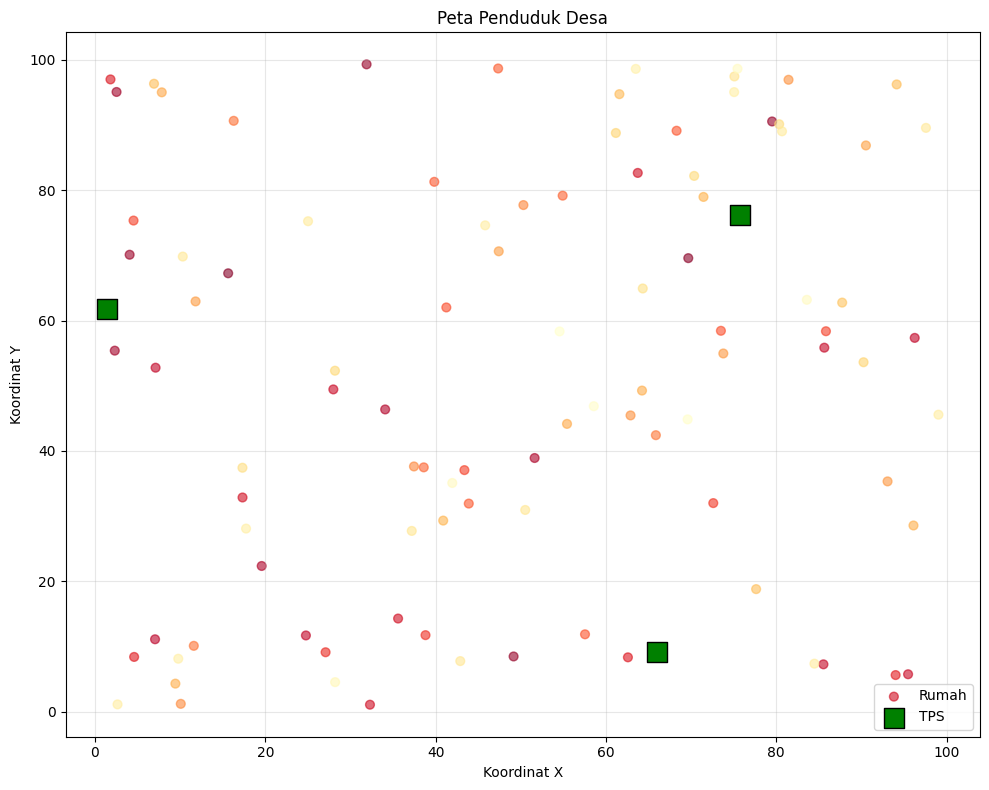

=== STATISTIK PENGELOLAAN ===
Total Jarak Semua Gerobak : 147.62 satuan
Total Jarak Semua Truk    : 27.08 satuan
Total Jarak Keseluruhan   : 174.70 satuan
Total Waktu Semua Gerobak : 1863.64 menit
Total Waktu Semua Truk    : 517.47 menit
Sisa Sampah di Rumah      : 0.00 kg
Sampah Tersimpan di Gerobak: 12.15 kg
Sampah Tersimpan di Truk   : 0.00 kg

=== SAMPLE REPORT PERGERAKAN ===
[6.28 Jam] G1: Ambil di Rumah 28 (7.00 kg)
[6.42 Jam] G1: Ambil di Rumah 18 (2.67 kg)
[6.53 Jam] G1: Ambil di Rumah 34 (1.73 kg)
[6.91 Jam] G1: Titip ke T1 (11.40 kg)
[7.15 Jam] G1: Ambil di Rumah 0 (5.70 kg)
[7.26 Jam] G1: Ambil di Rumah 24 (1.91 kg)
[6.28 Jam] G2: Ambil di Rumah 29 (6.98 kg)
[6.55 Jam] G2: Ambil di Rumah 74 (6.49 kg)
[7.00 Jam] G2: Titip ke T2 (13.47 kg)
[7.25 Jam] G2: Ambil di Rumah 71 (6.04 kg)
[7.41 Jam] G2: Ambil di Rumah 77 (3.21 kg)
[7.65 Jam] G2: Ambil di Rumah 15 (5.75 kg)
[8.38 Jam] T1: Terima dari G1 (11.40 kg)
[8.74 Jam] T1: Terima dari G1 (10.91 kg)
[9.24 Jam] T1: Terima dari G1 

In [7]:
# ## 2. Parameter Sistem
PARAMS = {
    'num_houses': 100,
    'waste_range': (0, 7),        # kg per rumah
    'cart_range': (5, 7),         # jumlah gerobak
    'truck_range': (2, 4),        # jumlah truk
    'cart_cap': 15.0,             # kg
    'truck_cap': 200.0,           # kg
    'tps_cap': (400.0, 500.0),    # kg per TPS
    'num_tps': 3,
    'cart_hours': (6*60, 15*60),  # 06:00 - 15:00 (menit)
    'truck_hours': (8*60, 17*60), # 08:00 - 17:00 (menit)
    'cart_load_min_per_kg': 2.0,  # menit/kg
    'cart_travel_min_per_unit': 3.0, # menit/satuan jarak
    'truck_load_min_per_10kg': 2.0, # menit/10kg
    'truck_travel_min_per_5unit': 3.0 # menit/5 satuan jarak
}

# ## 3. Generasi Data Desa
def generate_village():
    houses = pd.DataFrame({
        'id': range(1, PARAMS['num_houses'] + 1),
        'x': np.random.uniform(0, 100, PARAMS['num_houses']),
        'y': np.random.uniform(0, 100, PARAMS['num_houses']),
        'waste': np.random.uniform(*PARAMS['waste_range'], PARAMS['num_houses']).round(2)
    })
    
    # Matriks jarak (dinormalisasi ke skala 1-5 satuan)
    coords = houses[['x', 'y']].values
    dist_raw = cdist(coords, coords, metric='euclidean')
    dist_matrix = 1 + 4 * (dist_raw - dist_raw.min()) / (dist_raw.max() - dist_raw.min())
    
    # 3 TPS Strategis
    tps_idx = []
    remaining = list(range(len(houses)))
    for _ in range(PARAMS['num_tps']):
        c = max(remaining, key=lambda i: houses.iloc[i]['waste'])
        tps_idx.append(c)
        remaining = [i for i in remaining if dist_matrix[c, i] > 3]
        
    tps = pd.DataFrame({
        'id': [f'TPS-{i+1}' for i in range(PARAMS['num_tps'])],
        'x': [houses.iloc[i]['x'] for i in tps_idx],
        'y': [houses.iloc[i]['y'] for i in tps_idx],
        'capacity': np.random.uniform(*PARAMS['tps_cap'], PARAMS['num_tps']).round(1),
        'current_load': 0.0
    })
    return houses, tps, dist_matrix

houses, tps, dist_matrix = generate_village()
print(f"✓ Data Generated: {len(houses)} Rumah, {len(tps)} TPS")

# ## 4. Class Kendaraan (Vehicle)
class Vehicle:
    def __init__(self, vid, vtype, cap, start, end, is_truck=False):
        self.id, self.vtype, self.cap = vid, vtype, cap
        self.start, self.end, self.is_truck = start, end, is_truck
        self.pos = None
        self.time = start
        self.dist = 0.0
        self.load = 0.0
        self.logs = []  # Format: (time_in_minutes, action_text, amount_kg)
    
    def calc_travel_time(self, units):
        if self.is_truck:
            return (units / 5.0) * PARAMS['truck_travel_min_per_5unit']
        return units * PARAMS['cart_travel_min_per_unit']
    
    def calc_load_time(self, kg):
        if self.is_truck:
            return (kg / 10.0) * PARAMS['truck_load_min_per_10kg']
        return kg * PARAMS['cart_load_min_per_kg']
    
    def move_to(self, target_pos):
        raw = np.linalg.norm(np.array(self.pos) - np.array(target_pos))
        units = max(1.0, min(5.0, raw / 20.0))
        tt = self.calc_travel_time(units)
        if self.time + tt <= self.end:
            self.time += tt
            self.dist += units
            self.pos = np.array(target_pos, dtype=float)
            return True
        return False
    
    def load_waste(self, amt, src_name):
        if self.load + amt <= self.cap:
            lt = self.calc_load_time(amt)
            if self.time + lt <= self.end:
                self.time += lt
                self.load += amt
                self.logs.append((self.time, f"Ambil di {src_name}", amt))
                return True
        return False
    
    def unload(self, tgt_name, avail_cap):
        if self.load <= 0: return 0
        amt = min(self.load, avail_cap)
        if amt > 0:
            lt = self.calc_load_time(amt)
            if self.time + lt <= self.end:
                self.time += lt
                self.load -= amt
                self.logs.append((self.time, f"Buang ke {tgt_name}", amt))
                return amt
        return 0
    
    def transfer_to(self, other):
        if self.is_truck or not other.is_truck: return 0
        amt = min(self.load, other.cap - other.load)
        if amt > 0:
            tt = amt * PARAMS['cart_load_min_per_kg']
            if self.time + tt <= self.end and other.time + tt <= other.end:
                self.time += tt
                other.time += tt
                self.load -= amt
                other.load += amt
                self.logs.append((self.time, f"Titip ke {other.id}", amt))
                other.logs.append((other.time, f"Terima dari {self.id}", amt))
                return amt
        return 0

# ## 5. Inisialisasi Armada
def init_fleet(tps):
    carts, trucks = {}, {}
    for i in range(random.randint(*PARAMS['cart_range'])):
        c = Vehicle(f'G{i+1}', 'cart', PARAMS['cart_cap'], *PARAMS['cart_hours'])
        c.pos = tps.iloc[i % 3][['x', 'y']].values.astype(float)
        carts[c.id] = c
    for i in range(random.randint(*PARAMS['truck_range'])):
        t = Vehicle(f'T{i+1}', 'truck', PARAMS['truck_cap'], *PARAMS['truck_hours'], is_truck=True)
        t.pos = tps.iloc[i % 3][['x', 'y']].values.astype(float)
        trucks[t.id] = t
    return carts, trucks

carts, trucks = init_fleet(tps)
print(f"✓ Armada: {len(carts)} Gerobak, {len(trucks)} Truk")

# ## 6. Simulasi Routing
def run_simulation(houses, tps, carts, trucks):
    EPS = 0.01
    remaining = houses['waste'].copy()
    
    # FASE 1: Gerobak
    for cart in carts.values():
        unvisited = set(houses.index)
        max_iter = 500
        iter_count = 0
        while cart.time < cart.end and unvisited and iter_count < max_iter:
            iter_count += 1
            nearest, min_d = None, float('inf')
            for idx in unvisited:
                if remaining[idx] > EPS:
                    d = np.linalg.norm(cart.pos - houses.iloc[idx][['x','y']].values.astype(float))
                    if d < min_d: min_d, nearest = d, idx
            if nearest is None: break
            
            target = houses.iloc[nearest][['x','y']].values.astype(float)
            if not cart.move_to(target): break
            
            take = min(remaining[nearest], cart.cap - cart.load)
            if take > EPS and cart.load_waste(take, f"Rumah {nearest}"):
                remaining[nearest] -= take
                if remaining[nearest] <= EPS: unvisited.remove(nearest)
            
            # Transfer ke truk
            if cart.load > PARAMS['cart_cap'] * 0.7:
                for truck in trucks.values():
                    if truck.time < truck.end and truck.load < truck.cap:
                        if np.linalg.norm(cart.pos - truck.pos) < 30:
                            cart.transfer_to(truck)
                            break
            
            # Buang ke TPS jika penuh
            if cart.load >= PARAMS['cart_cap'] - EPS:
                tps_coords = tps[['x','y']].values.astype(float)
                tps_d = cdist([cart.pos], tps_coords)[0]
                target_tps = tps.iloc[int(np.argmin(tps_d))]
                if cart.move_to(target_tps[['x','y']].values.astype(float)):
                    cap_avail = target_tps['capacity'] - target_tps['current_load']
                    unloaded = cart.unload(target_tps['id'], cap_avail)
                    if unloaded > EPS:
                        idx = tps[tps['id']==target_tps['id']].index[0]
                        tps.loc[idx, 'current_load'] += unloaded
                else: break
        
        # Cleanup akhir shift
        if cart.load > EPS and cart.time < cart.end:
            tps_coords = tps[['x','y']].values.astype(float)
            target_tps = tps.iloc[int(np.argmin(cdist([cart.pos], tps_coords)[0]))]
            if cart.move_to(target_tps[['x','y']].values.astype(float)):
                cart.unload(target_tps['id'], target_tps['capacity'] - target_tps['current_load'])

    # FASE 2: Truk
    for truck in trucks.values():
        max_iter = 200
        iter_count = 0
        while truck.time < truck.end and iter_count < max_iter:
            iter_count += 1
            active = tps[tps['current_load'] > EPS]
            if active.empty: break
            
            tps_coords = active[['x','y']].values.astype(float)
            tps_d = cdist([truck.pos], tps_coords)[0]
            target_tps = active.iloc[int(np.argmin(tps_d))]
            
            if not truck.move_to(target_tps[['x','y']].values.astype(float)): break
            
            take = min(target_tps['current_load'], truck.cap - truck.load)
            if take > EPS and truck.load_waste(take, target_tps['id']):
                tps.loc[tps['id']==target_tps['id'], 'current_load'] -= take
            
            if truck.load >= PARAMS['truck_cap'] - EPS:
                main = tps.iloc[0]
                if truck.move_to(main[['x','y']].values.astype(float)):
                    truck.unload(main['id'], main['capacity'])
                else: break
        
        if truck.load > EPS and truck.time < truck.end:
            main = tps.iloc[0]
            if truck.move_to(main[['x','y']].values.astype(float)):
                truck.unload(main['id'], main['capacity'])
                
    return remaining

print("🔄 Running Simulation...")
final_remaining = run_simulation(houses, tps, carts, trucks)
print("✅ Simulation Finished.")

# ## 7. Visualisasi Peta Penduduk
plt.figure(figsize=(10, 8))
plt.scatter(houses['x'], houses['y'], c=houses['waste'], cmap='YlOrRd', s=40, alpha=0.6, label='Rumah')
plt.scatter(tps['x'], tps['y'], c='green', s=200, marker='s', edgecolors='black', label='TPS')
plt.title('Peta Penduduk Desa')
plt.xlabel('Koordinat X'); plt.ylabel('Koordinat Y')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ## 8. Laporan Output
def generate_report(carts, trucks, tps, houses, remaining):
    total_cart_dist = sum(c.dist for c in carts.values())
    total_truck_dist = sum(t.dist for t in trucks.values())
    total_cart_time = sum(c.time - c.start for c in carts.values())
    total_truck_time = sum(t.time - t.start for t in trucks.values())
    rem_house = remaining.sum()
    rem_carts = sum(c.load for c in carts.values())
    rem_trucks = sum(t.load for t in trucks.values())
    
    print("=== STATISTIK PENGELOLAAN ===")
    print(f"Total Jarak Semua Gerobak : {total_cart_dist:.2f} satuan")
    print(f"Total Jarak Semua Truk    : {total_truck_dist:.2f} satuan")
    print(f"Total Jarak Keseluruhan   : {total_cart_dist + total_truck_dist:.2f} satuan")
    print(f"Total Waktu Semua Gerobak : {total_cart_time:.2f} menit")
    print(f"Total Waktu Semua Truk    : {total_truck_time:.2f} menit")
    print(f"Sisa Sampah di Rumah      : {rem_house:.2f} kg")
    print(f"Sampah Tersimpan di Gerobak: {rem_carts:.2f} kg")
    print(f"Sampah Tersimpan di Truk   : {rem_trucks:.2f} kg")
    
    print("\n=== SAMPLE REPORT PERGERAKAN ===")
    for c in list(carts.values())[:2]:
        for entry in c.logs[:6]:
            print(f"[{entry[0]/60:.2f} Jam] {c.id}: {entry[1]} ({entry[2]:.2f} kg)")
    for t in list(trucks.values())[:2]:
        for entry in t.logs[:6]:
            print(f"[{entry[0]/60:.2f} Jam] {t.id}: {entry[1]} ({entry[2]:.2f} kg)")

generate_report(carts, trucks, tps, houses, final_remaining)